In [1]:
## 2026.02.11 using FineST env
## 2026.02.12 vilization cell type of each ROI
## 2026.03.04 woody_pro:: upload the HE-StarDist embedding and predict the cell type of NCRT_tumor1  
## 2026.03.06 woody_pro:: clearn code 
## 2026.03.13 update cell type level1: nanually make codex_meta_celltype_level1.csv 
## 2026.03.16 use valis to make registration [dont try]
## 2026.03.18 delete two subtypes, adjust scale factor by batch

## Load anno data

In [33]:
import sys
import os
import pandas as pd
import importlib

## Add the code directory to Python path
path = '/home/lingyu/ssd2/Python/'
code_dir = f'{path}Hist2Pheno/code/Hist2Pheno_pkg'
if code_dir not in sys.path:
    sys.path.insert(0, code_dir)

## Import (or reload) base module
import base
import plot
## Impost：Force reload base.py
importlib.reload(base)  
importlib.reload(plot)  

## Re-import the function (otherwise, still be old_version).
from base import (
    get_celltype_coords,
    divide_into_rois_by_parent,
    get_pixel_size,
    visualize_roi_cells,
    visualize_all_rois_with_he,
    visualize_all_rois,
    extract_and_save_celltype_by_tumorid,
    transformation_matrix_properties,
    invert_transformation_matrix,
    align_pcf_to_he_coordinates,
    add_pixel_coords,
    verify_transformation_alignment,
    merge_coordinates,
    analyze_and_filter_classes_by_gap,
    ImprovedMLPClassifier,
    load_embeddings,
    match_embeddings,
    prepare_matched_embeddings,
    evaluate,
    plot_confusion_matrix,
    plot_per_class_f1,
    create_dataloaders,
    train_model,
    CellTypeDataset,
    evaluate_and_plot_on_all_data,
    align_matrix,
    match_StarCoords2ROI,
    match_celltype2stardist,
    merge_celltype_level12,
    make_PCF2HE_alignment
)

from plot import (
    plot_celltype_distribution,
    visualize_all_celltype_distributions,
    plot_celltype_distribution,
    plot_celltype_spatial_distribution,
    plot_PCF_HE_counts,
    plot_WSI_counts,
    plot_cell_area_histogram
)

## Import HAS_OPENSLIDE and HAS_TIFFFILE from base module for use in notebook
HAS_OPENSLIDE = base.HAS_OPENSLIDE
HAS_TIFFFILE = base.HAS_TIFFFILE

## Also import openslide module if available (needed for direct use in some cells)
if HAS_OPENSLIDE:
    import openslide
else:
    openslide = None

try:
    import tifffile
except ImportError:
    tifffile = None

print("Successfully reloaded functions from base.py")
print(f"openslide: {HAS_OPENSLIDE}, tifffile: {HAS_TIFFFILE}")


## reset pathway
os.chdir(f'{path}Hist2Pheno/data/CODEX/ESCC')
therapy_data = 'NCRT'
segment_data1 = 'NCRT_project - seg 1-14'
segment_data2 = 'NCRT_project - seg 15-28'
export_data = 'export'
save_result = 'result'

Successfully reloaded functions from base.py
openslide: True, tifffile: True


### Load GT

In [3]:
celltype_level2_path = f'{path}Hist2Pheno/data/CODEX/ESCC/codex_meta_celltype.csv'
celltype_level1_path = f'{path}Hist2Pheno/data/CODEX/ESCC/codex_meta_celltype_level1.csv'
celltype_anno_path = f'{path}Hist2Pheno/data/CODEX/ESCC/codex_meta_celltype_final.csv'
# celltype_anno_df = merge_celltype_level12(celltype_level1_path, celltype_level2_path, celltype_anno_path, run=True)
celltype_anno_df = merge_celltype_level12(celltype_level1_path, celltype_level2_path, celltype_anno_path, run=False)
celltype_anno_df.head()

The number of cells after deleting 'Low_quality' and 'non_specific' cells: 10365126
The number of cell types level2: 40
The number of cell types level1: 7


,Unnamed: 0,CellID,TumorID,celltype,celltype_level1
0,S_1,38b0fa79-483d-4a28-be51-50967be5dcdb,S_tumor2,Treg,CD4+T
1,S_2,cd3415e0-f771-41aa-8691-8ba7c8bd0622,S_tumor2,Bn,B
2,S_3,f7fa5bf3-e070-423c-8012-2ac7e066f456,S_tumor2,B_other,B
3,S_4,3e7ca82c-4f00-474d-b74c-5db5abf42dd7,S_tumor2,B_other,B
4,S_5,a6beba40-b49e-4597-ab1a-8d1f2061163a,S_tumor2,B_other,B


In [ ]:
celltype_coords_df1 = pd.read_csv(f'{therapy_data}/{segment_data1}/{export_data}/{therapy_data}-measurements-tumor1-14.csv')
celltype_coords_df2 = pd.read_csv(f'{therapy_data}/{segment_data2}/{export_data}/{therapy_data}-measurements-tumor-15-28.csv')
celltype_coords_df = pd.concat([celltype_coords_df1, celltype_coords_df2], ignore_index=True)
print("Cell numbers of 1-14:", celltype_coords_df1.shape)
print("Cell numbers of 15-28:", celltype_coords_df2.shape)
print("Cell numbers of 1-28:", celltype_coords_df.shape)
celltype_coords_df.head()

Cell numbers of 1-14: (870924, 58)
Cell numbers of 15-28: (1021484, 58)
Cell numbers of 1-28: (1892408, 58)


,Image,Object ID,Name,Class,Parent,ROI,Centroid X µm,Centroid Y µm,Detection probability,Nucleus: Area µm^2,...,PD-1: Cell: Mean,CD14: Cell: Mean,CD27: Cell: Mean,CD123: Cell: Mean,Granzyme B: Cell: Mean,c-PARP: Nucleus: Mean,CD38: Cell: Mean,LAG3: Cell: Mean,TCF-1: Nucleus: Mean,PD-L1: Cell: Mean
0,NCRT PCF.qptiff - resolution #1,e071bc4e-01bc-4831-a466-25be5330e3df,PathCellObject,NaN,tumor1,Polygon,4159.0,1.242,0.5100,3.9411,...,198.2059,188.0294,13.0588,12.4118,0.0000,1.6875,0.0000,33.8529,144.6875,33.2647
1,NCRT PCF.qptiff - resolution #1,99103727-0736-484a-93b0-f83efe823c03,PathCellObject,NaN,tumor1,Polygon,3970.5,2.817,0.8954,12.8580,...,198.8849,902.8584,39.9646,61.3628,0.1947,42.9184,7.4248,91.5575,178.2857,102.2389
2,NCRT PCF.qptiff - resolution #1,4882bef1-7690-443b-8e2c-512d3e81c77b,PathCellObject,NaN,tumor1,Polygon,4027.5,2.793,0.8912,30.7944,...,151.2155,2110.7844,15.8190,24.5216,0.0000,12.0635,0.3405,82.9138,138.8651,39.8319
3,NCRT PCF.qptiff - resolution #1,1e0d319a-d7c0-4c2a-85d1-08cfc6e42523,PathCellObject,NaN,tumor1,Polygon,4172.1,3.086,0.8751,28.3653,...,41.6081,88.2297,58.7523,6.5405,0.0000,1.8509,0.1171,22.0045,35.0351,11.9595
4,NCRT PCF.qptiff - resolution #1,ff987357-f306-42ab-8e03-233ac4f5e850,PathCellObject,NaN,tumor1,Polygon,3996.6,3.635,0.6372,30.5691,...,79.1639,1005.8992,7.1471,5.0840,0.0000,1.4878,0.0000,85.4328,33.2439,17.2185


In [28]:
print("The number of ROIs", len(celltype_anno_df['TumorID'].unique()))
celltype_NCRT_tumor1 = celltype_anno_df[celltype_anno_df['TumorID'] == 'NCRT_tumor1']
print("The number of cells in NCRT_tumor1", celltype_NCRT_tumor1.shape[0])
celltype_NCRT_tumor1.head()

The number of ROIs 140
The number of cells in NCRT_tumor1 80303


,Unnamed: 0,CellID,TumorID,celltype,celltype_level1
4951957,NCRT_1,e071bc4e-01bc-4831-a466-25be5330e3df,NCRT_tumor1,CAF_other,Stromal
4951958,NCRT_2,99103727-0736-484a-93b0-f83efe823c03,NCRT_tumor1,Neutrophil,Myeloid
4951959,NCRT_3,4882bef1-7690-443b-8e2c-512d3e81c77b,NCRT_tumor1,Monocyte,Myeloid
4951960,NCRT_4,1e0d319a-d7c0-4c2a-85d1-08cfc6e42523,NCRT_tumor1,CAF_other,Stromal
4951961,NCRT_5,ff987357-f306-42ab-8e03-233ac4f5e850,NCRT_tumor1,Monocyte,Myeloid


In [6]:
# ## extract and save cell type information for all TumorIDs
# saved_files_info = extract_and_save_celltype_by_tumorid(celltype_anno_df, base_path=f'{path}Hist2Pheno/data/CODEX/ESCC/')

In [7]:
# ## Call the function to batch visualize all folders
# visualize_all_celltype_distributions(base_path=f'{path}Hist2Pheno/data/CODEX/ESCC/codex_celltype')

The number of cells in celltype: 10365126
The distribution of celltype: celltype
CD8_Tpex                 1329760
Muscle&mCAF              1197496
CAF_other                 853404
Treg                      813448
Tumor_PDL1pos_MHCIpos     770217
Plasma                    738198
Endothelial               537909
Epithelial                496437
CD4_Tex                   418058
Monocyte                  385513
Macro_other               288451
Tumor_PDL1neg_MHCIpos     239810
Neutrophil                231752
CD8_Tex                   208595
Bm_unswitched             150591
Bm_switched               136771
Tumor_PDL1neg_MHCIneg     135267
Th17                      113394
CAF_ap                    109152
pDC                       105455
DC_mature                 100480
B_other                   100161
Tumor_PDL1pos_MHCIneg      88774
B_proliferating            79780
CD8_Teff                   79152
CD8_Tem                    74785
CD4_Tem                    67175
Macro_M1                   6

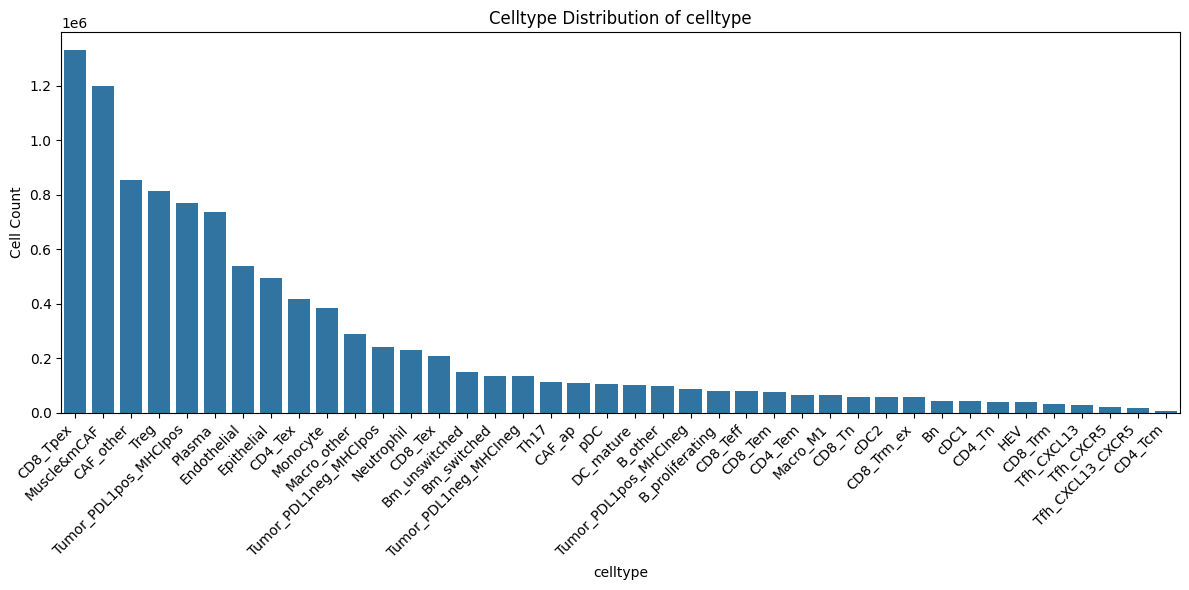

The number of cells in celltype_level1: 10365126
The distribution of celltype_level1: celltype_level1
Stromal       2736176
CD8+T         1840623
CD4+T         1528471
Myeloid       1279134
B             1250217
Tumor         1234068
Epithelial     496437
Name: count, dtype: int64


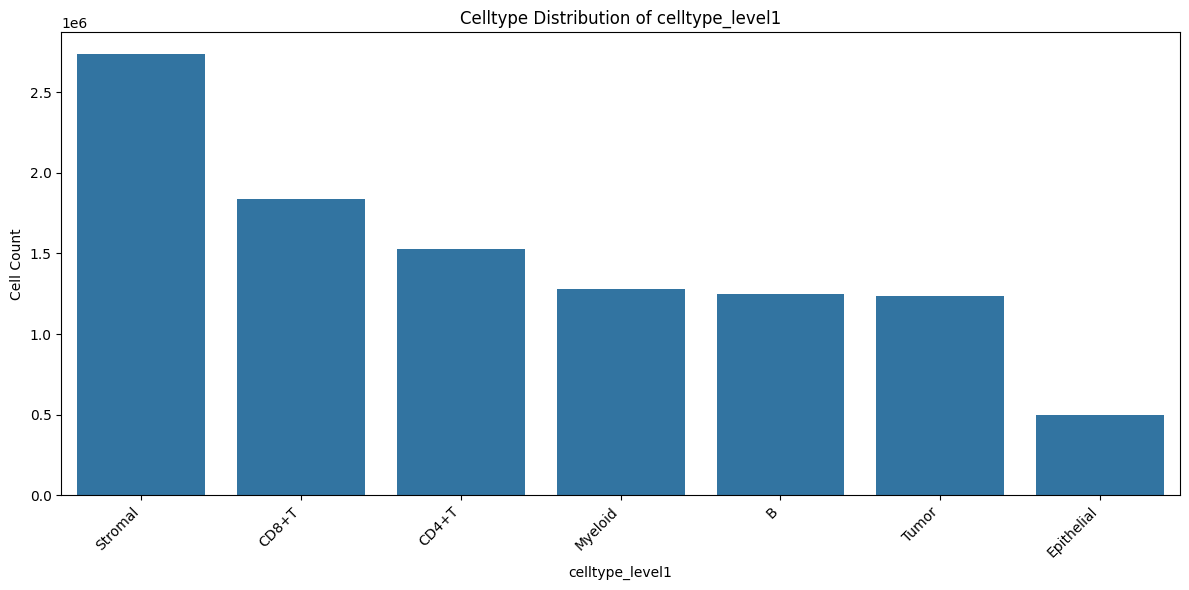

In [8]:
plot_celltype_distribution(celltype_anno_df, 
                            celltype_col='celltype',
                            save_path=None)
                            # save_path=f'{therapy_data}/{save_result}/celltype_dist_level2.pdf')

plot_celltype_distribution(celltype_anno_df, 
                            celltype_col='celltype_level1',
                            save_path=None)
                            # save_path=f'{therapy_data}/{save_result}/celltype_dist_level1.pdf')

The number of cells in celltype: 80303
The distribution of celltype: celltype
Epithelial               16508
Muscle&mCAF               7372
Plasma                    6308
CD8_Tpex                  5978
Monocyte                  4767
Treg                      4520
CAF_other                 4181
Tumor_PDL1pos_MHCIpos     3801
Tumor_PDL1neg_MHCIpos     3526
Macro_other               3355
Neutrophil                3075
Endothelial               2881
CD4_Tex                   2502
CD8_Tex                   2310
Tumor_PDL1neg_MHCIneg     2263
Macro_M1                  1023
DC_mature                  747
pDC                        738
CD8_Teff                   723
CD8_Trm_ex                 444
B_other                    426
Bm_switched                376
Bm_unswitched              354
cDC2                       294
CD4_Tem                    274
CAF_ap                     223
cDC1                       219
Th17                       200
CD8_Tn                     165
Tfh_CXCL13_CXCR5       

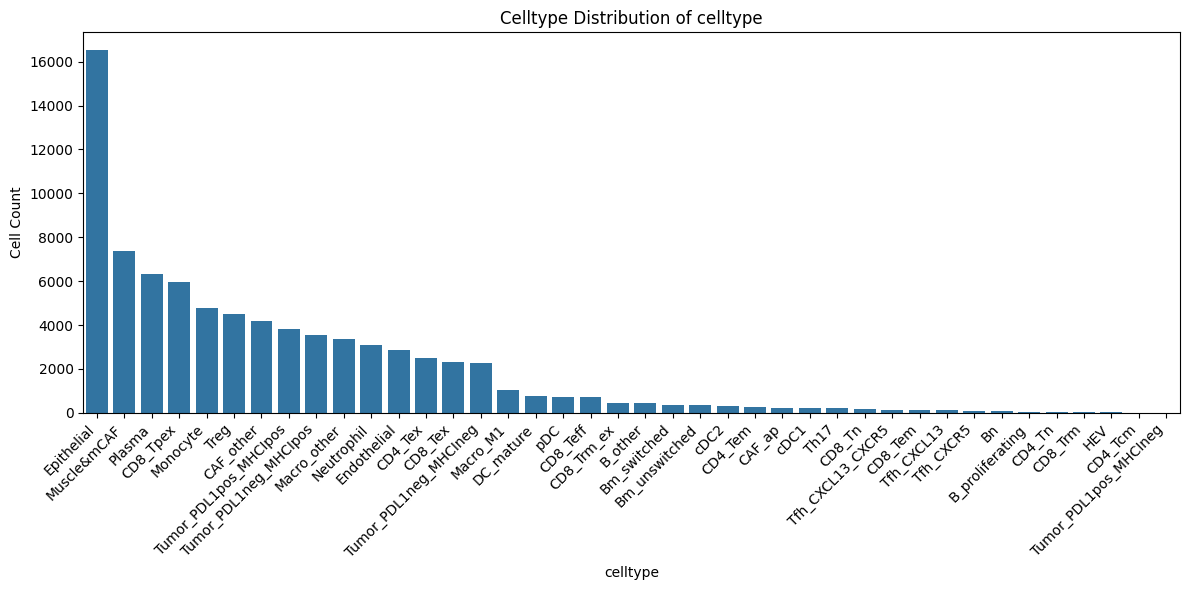

The number of cells in celltype_level1: 80303
The distribution of celltype_level1: celltype_level1
Epithelial    16508
Stromal       14692
Myeloid       14218
CD8+T          9815
Tumor          9591
CD4+T          7887
B              7592
Name: count, dtype: int64


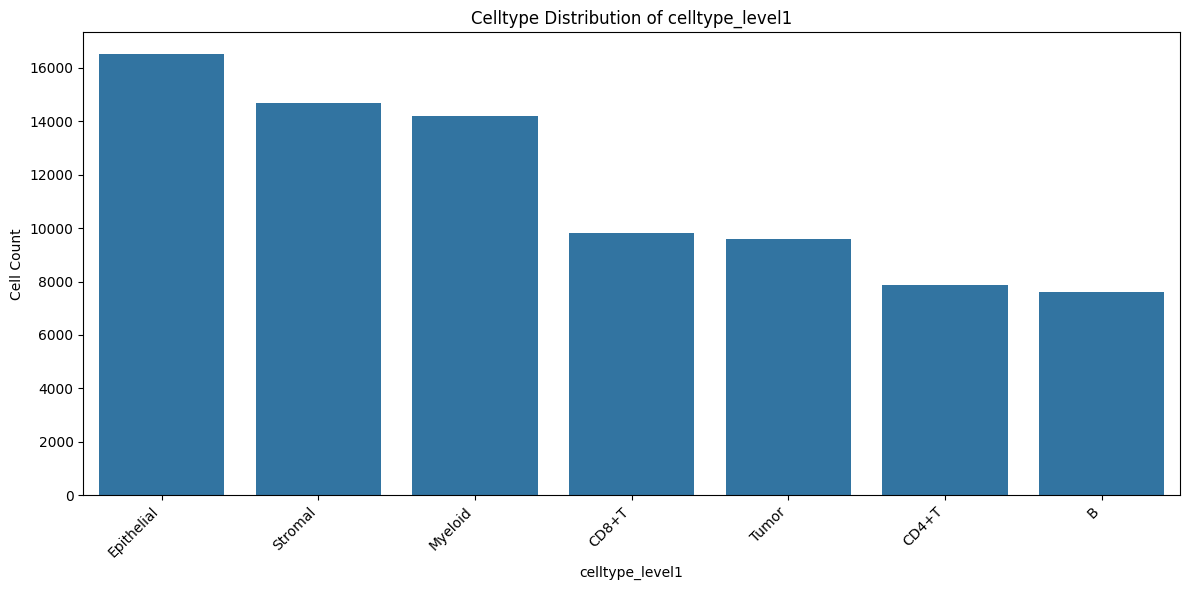

In [9]:
plot_celltype_distribution(celltype_NCRT_tumor1, 
                            celltype_col='celltype',
                            save_path=None)
                            # save_path=f'{therapy_data}/{save_result}/celltype_dist_tumor1_level2.pdf')

plot_celltype_distribution(celltype_NCRT_tumor1, 
                            celltype_col='celltype_level1',
                            save_path=None)
                            # save_path=f'{therapy_data}/{save_result}/celltype_dist_tumor1_level1.pdf')

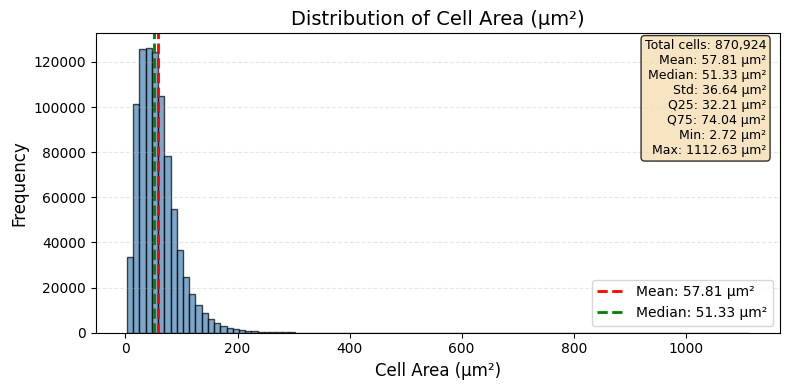


Summary Statistics for 'Cell: Area µm^2':
  Total cells: 870,924
  Mean: 57.81 µm²
  Median: 51.33 µm²
  Standard deviation: 36.64 µm²
  Range: [2.72, 1112.63] µm²
  IQR: [32.21, 74.04] µm²


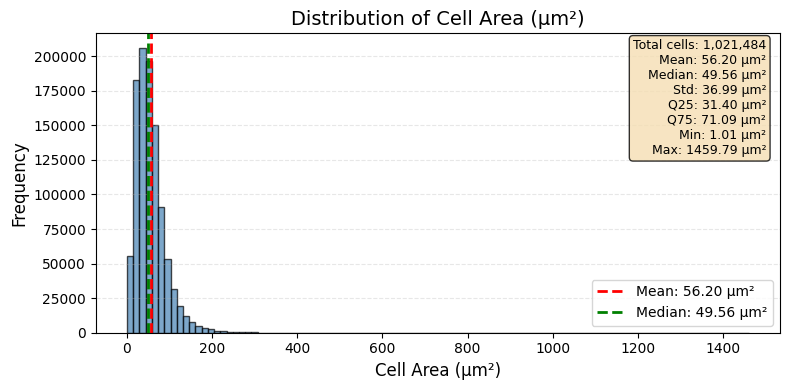


Summary Statistics for 'Cell: Area µm^2':
  Total cells: 1,021,484
  Mean: 56.20 µm²
  Median: 49.56 µm²
  Standard deviation: 36.99 µm²
  Range: [1.01, 1459.79] µm²
  IQR: [31.40, 71.09] µm²


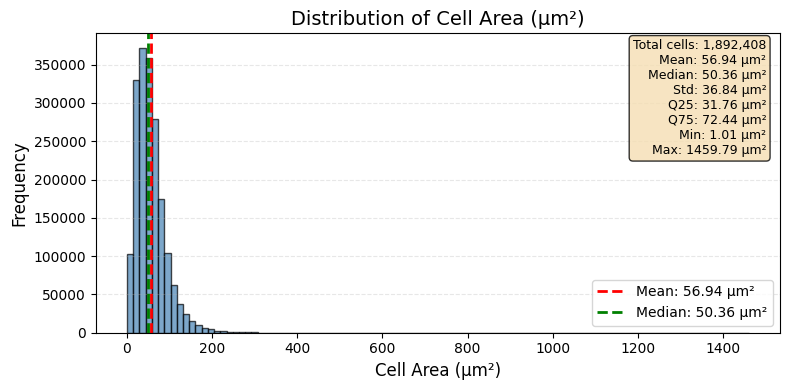


Summary Statistics for 'Cell: Area µm^2':
  Total cells: 1,892,408
  Mean: 56.94 µm²
  Median: 50.36 µm²
  Standard deviation: 36.84 µm²
  Range: [1.01, 1459.79] µm²
  IQR: [31.76, 72.44] µm²


In [10]:
plot_cell_area_histogram(celltype_coords_df1, 
                        save_path=None)
                        # save_path=f'{therapy_data}/{save_result}/cellarea_dist_1_14.pdf')
plot_cell_area_histogram(celltype_coords_df2, 
                        save_path=None)
                        # save_path=f'{therapy_data}/{save_result}/cellarea_dist_15_28.pdf')
plot_cell_area_histogram(celltype_coords_df, 
                        save_path=None)
                        # save_path=f'{therapy_data}/{save_result}/cellarea_dist.pdf')

In [11]:
## celltype_NCRT_tumor1
celltype_NCRT_tumor1 = get_celltype_coords(celltype_anno_df, celltype_coords_df, value='NCRT_tumor1', parent_value='tumor1')
celltype_NCRT_tumor1.head()

['Unnamed: 0', 'CellID', 'TumorID', 'celltype', 'celltype_level1']
Before filtering - ncrt_anno_df1 shape: (1892408, 58)
Unique Parent values:
 ['tumor1' 'tumor2' 'tumor3' 'tumor4' 'tumor5' 'tumor6' 'tumor7' 'tumor8'
 'tumor9' 'tumor10' 'tumor11' 'tumor12' 'tumor13' 'tumor14' 'tumor15'
 'tumor16' 'tumor17' 'tumor18' 'tumor19' 'tumor20' 'tumor21' 'tumor22'
 'tumor23' 'tumor24' 'tumor25' 'tumor26' 'tumor28' 'tumor27']
After filtering for 'tumor1' - ncrt_anno_df1_tumor1 shape: (82805, 58)
Number of cells in tumor1: 82805

Shape of celltype_NCRT_tumor1 before merging: (80303, 5)
Shape of ncrt_anno_df1_tumor1: (82805, 58)
Shape of celltype_NCRT_tumor1 after merging: (80303, 7)

Columns after merging: ['Unnamed: 0', 'CellID', 'TumorID', 'celltype', 'celltype_level1', 'Centroid X µm', 'Centroid Y µm']
Successfully matched cells: 80303 / 80303 (100.00%)


,Unnamed: 0,CellID,TumorID,celltype,celltype_level1,Centroid X µm,Centroid Y µm
0,NCRT_1,e071bc4e-01bc-4831-a466-25be5330e3df,NCRT_tumor1,CAF_other,Stromal,4159.0,1.242
1,NCRT_2,99103727-0736-484a-93b0-f83efe823c03,NCRT_tumor1,Neutrophil,Myeloid,3970.5,2.817
2,NCRT_3,4882bef1-7690-443b-8e2c-512d3e81c77b,NCRT_tumor1,Monocyte,Myeloid,4027.5,2.793
3,NCRT_4,1e0d319a-d7c0-4c2a-85d1-08cfc6e42523,NCRT_tumor1,CAF_other,Stromal,4172.1,3.086
4,NCRT_5,ff987357-f306-42ab-8e03-233ac4f5e850,NCRT_tumor1,Monocyte,Myeloid,3996.6,3.635


### Visualization CODEX tumorX

Number of valid data points: 80303
Number of cell types: 40


(<Figure size 1200x1000 with 1 Axes>,
 <Axes: title={'center': 'celltype Spatial Distribution'}, xlabel='Centroid X µm', ylabel='Centroid Y µm'>)

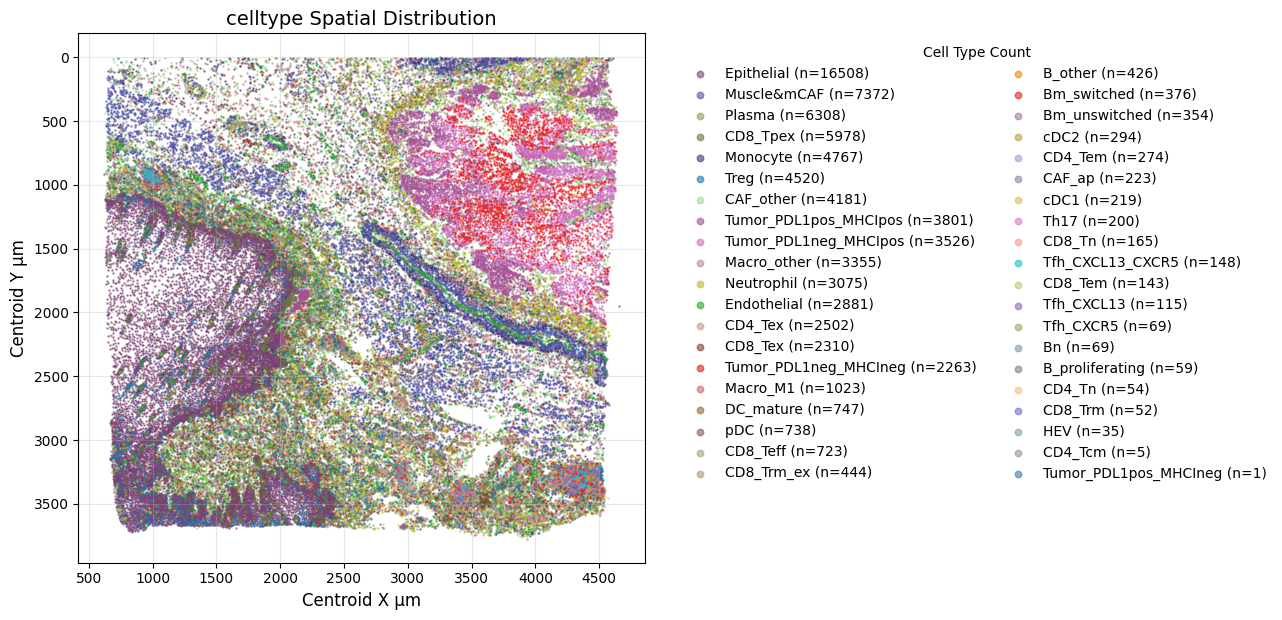

In [12]:
## Plot the spatial distribution of cell types in celltype_NCRT_tumor1
plot_celltype_spatial_distribution(celltype_NCRT_tumor1,
                                   x_col='Centroid X µm', y_col='Centroid Y µm',
                                   celltype_col='celltype',
                                   figsize=(12, 10), alpha=0.6,s=0.6,
                                    # format='jpg', save_path=None)
                                    format='jpg', save_path=f'{therapy_data}/{save_result}/celltype_spatial_tumor1_level2.jpg')

Number of valid data points: 80303
Number of cell types: 40


(<Figure size 1200x1000 with 1 Axes>,
 <Axes: title={'center': 'celltype_level1 Spatial Distribution'}, xlabel='Centroid X µm', ylabel='Centroid Y µm'>)

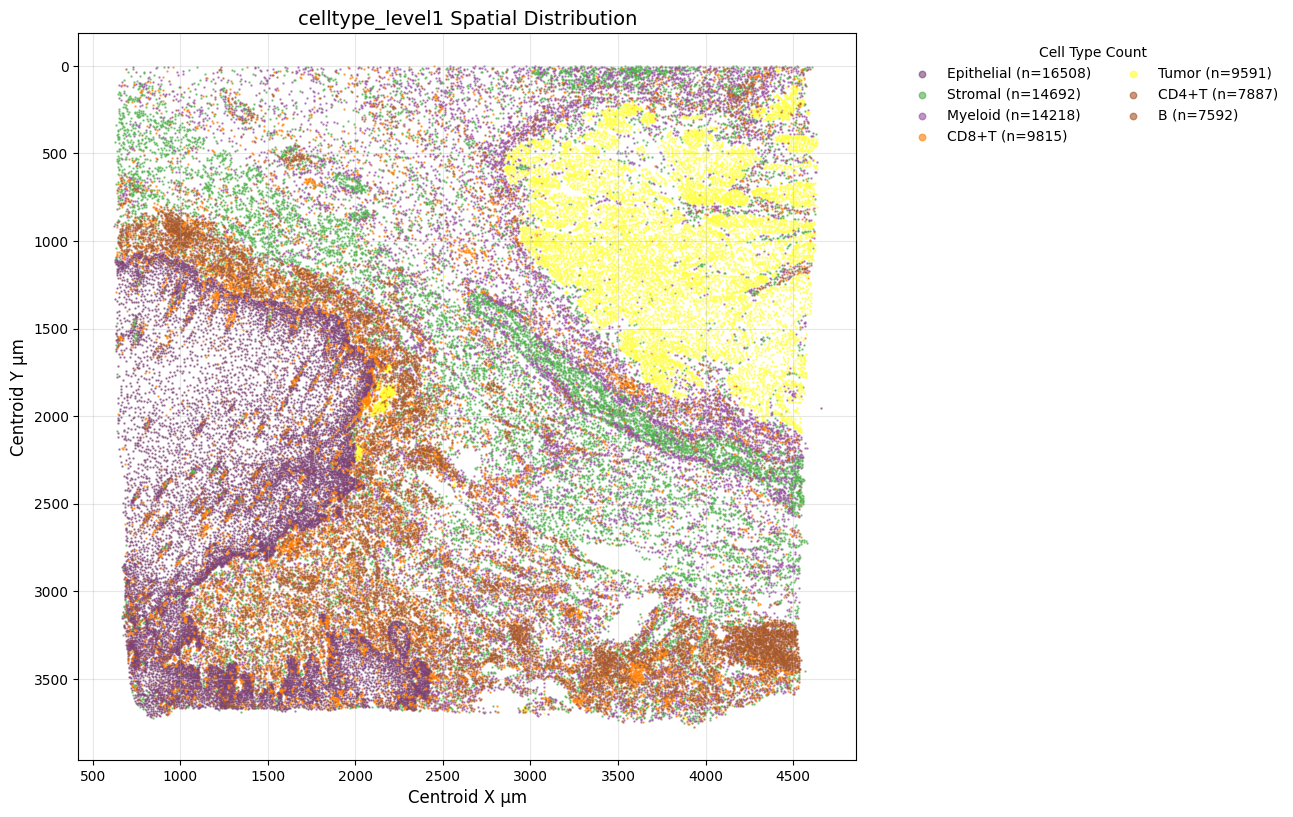

In [13]:
plot_celltype_spatial_distribution(celltype_NCRT_tumor1,
                                   x_col='Centroid X µm', y_col='Centroid Y µm',
                                   celltype_col='celltype_level1',
                                   figsize=(12, 10), alpha=0.6,s=0.6,
                                    # format='jpg', save_path=None)
                                    format='jpg', save_path=f'{therapy_data}/{save_result}/celltype_spatial_tumor1_level1.jpg')

In [14]:
# ## celltype_NCRT_tumor5
# celltype_NCRT_tumor5 = get_celltype_coords(celltype_anno_df, celltype_coords_df1, value='NCRT_tumor5', parent_value='tumor5')
# # celltype_NCRT_tumor5.head()
# plot_celltype_spatial_distribution(celltype_NCRT_tumor5,
#                                    x_col='Centroid X µm', y_col='Centroid Y µm',
#                                    celltype_col='celltype',
#                                    figsize=(12, 10), alpha=0.6,s=0.6,
#                                    # format='jpg', save_path=None)  
#                                     format='jpg', save_path=f'{therapy_data}/{save_result}/celltype_spatial_tumor5_level2.jpg')
# plot_celltype_spatial_distribution(celltype_NCRT_tumor5,
#                                    x_col='Centroid X µm', y_col='Centroid Y µm',
#                                    celltype_col='celltype_level1',
#                                    figsize=(12, 10), alpha=0.6,s=0.6,
#                                    # format='jpg', save_path=None)  
#                                     format='jpg', save_path=f'{therapy_data}/{save_result}/celltype_spatial_tumor5_level1.jpg')

### Alignment: Coordinates transform: PCF -> HE

- Transformation matrix exported from QuPath: [up: HE; down: PCF]
- Here, In QuPath, NCRT PCF.qptiff is the reference (front) and NCRT HE.qptiff is the target (back)
- QuPath shows HE->PCF, we need PCF->HE (INVERT the matrix)

In [29]:
## Load images
he_path  = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/NCRT HE.qptiff'
pcf_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/NCRT PCF.qptiff'
segment_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{segment_data1}'
he_cell_coords_path = f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/{therapy_data}_CellPixCoords.csv'
he_cell_coords4ViT_path = f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/{therapy_data}_CellPixCoords4ViT.csv'

he_cell_coords_tumor1_path = f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/{therapy_data}_CellPixCoords_tumor1.csv'
he_cell_coords4ViT_tumor1_path = f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/{therapy_data}_CellPixCoords4ViT_tumor1.csv'

In [25]:
####################################
# celltype_pixel_NCRT
####################################
celltype_pixel_NCRT = make_PCF2HE_alignment(celltype_anno_df, celltype_coords_df, 
                                            therapy_data, segment_path, 
                                            segment_batch1='1', segment_batch2='3', 
                                            value='NCRT', parent_value=None,
                                            # save_path=he_cell_coords_path, save_path4ViT=he_cell_coords4ViT_path)
                                            save_path=None, save_path4ViT=None)

Original QuPath matrix (HE -> PCF):
[[ 9.83752773e-01 -7.72653508e-03 -5.46157726e+03]
 [ 7.72653508e-03  9.83752773e-01 -2.10318222e+03]]

Matrix properties (HE -> PCF):
  Scale: 0.9838, Rotation: 0.4427°
  Translation: X=-5461.6, Y=-2103.2

Inverted matrix (PCF -> HE):
[[ 1.01645286e+00  7.98336622e-03  5.56822628e+03]
 [-7.98336622e-03  1.01645286e+00  2.09418381e+03]]

Matrix properties (PCF -> HE):
  Scale: 1.0165, Rotation: -0.4574°
  Translation: X=5568.2, Y=2094.2
pixel_size_um read from server.json: 0.508248 µm
width read from server.json: 35520
height read from server.json: 66240
pixel_size_um read from server.json: 0.500006 µm
width read from server.json: 47040
height read from server.json: 70560
['Unnamed: 0', 'CellID', 'TumorID', 'celltype', 'celltype_level1']
Dont filtering - parent value: 'Parent' column
Available columns: ['Image', 'CellID', 'Name', 'Class', 'Parent', 'ROI', 'Centroid X µm', 'Centroid Y µm', 'Detection probability', 'Nucleus: Area µm^2']
Shape of cellty

In [30]:
print("Cell numbers with NCRT:", celltype_pixel_NCRT.shape[0])
celltype_pixel_NCRT.head()

Cell numbers with NCRT: 1746948


,Unnamed: 0,CellID,TumorID,celltype,celltype_level1,Centroid X µm,Centroid Y µm,X_pix_PCF,Y_pix_PCF,pxl_row_in_fullres,pxl_col_in_fullres,X_um_HE,Y_um_HE
0,NCRT_1,e071bc4e-01bc-4831-a466-25be5330e3df,NCRT_tumor1,CAF_other,Stromal,4159.0,1.242,8183.007536,2.443687,13885.887175,2031.339753,6943.028787,1015.682340
1,NCRT_2,99103727-0736-484a-93b0-f83efe823c03,NCRT_tumor1,Neutrophil,Myeloid,3970.5,2.817,7812.125853,5.542566,13508.928169,2037.450502,6754.546971,1018.737752
2,NCRT_3,4882bef1-7690-443b-8e2c-512d3e81c77b,NCRT_tumor1,Monocyte,Myeloid,4027.5,2.793,7924.275751,5.495345,13622.922877,2036.507170,6811.545024,1018.266080
3,NCRT_4,1e0d319a-d7c0-4c2a-85d1-08cfc6e42523,NCRT_tumor1,CAF_other,Stromal,4172.1,3.086,8208.782337,6.071835,13912.115011,2034.821824,6956.142865,1017.423397
4,NCRT_5,ff987357-f306-42ab-8e03-233ac4f5e850,NCRT_tumor1,Monocyte,Myeloid,3996.6,3.635,7863.478701,7.152015,13561.138767,2038.676462,6780.652590,1019.350740


In [35]:
####################################
# celltype_pixel_NCRT
####################################
celltype_pixel_NCRT_tumor1 = make_PCF2HE_alignment(celltype_anno_df, celltype_coords_df, 
                                            therapy_data, segment_path, 
                                            segment_batch1='1', segment_batch2='3', 
                                            value='NCRT', parent_value='tumor1',
                                            # save_path=he_cell_coords_tumor1_path, save_path4ViT=he_cell_coords4ViT_tumor1_path)
                                            save_path=None, save_path4ViT=None)

Original QuPath matrix (HE -> PCF):
[[ 9.83752773e-01 -7.72653508e-03 -5.46157726e+03]
 [ 7.72653508e-03  9.83752773e-01 -2.10318222e+03]]

Matrix properties (HE -> PCF):
  Scale: 0.9838, Rotation: 0.4427°
  Translation: X=-5461.6, Y=-2103.2

Inverted matrix (PCF -> HE):
[[ 1.01645286e+00  7.98336622e-03  5.56822628e+03]
 [-7.98336622e-03  1.01645286e+00  2.09418381e+03]]

Matrix properties (PCF -> HE):
  Scale: 1.0165, Rotation: -0.4574°
  Translation: X=5568.2, Y=2094.2
pixel_size_um read from server.json: 0.508248 µm
width read from server.json: 35520
height read from server.json: 66240
pixel_size_um read from server.json: 0.500006 µm
width read from server.json: 47040
height read from server.json: 70560
['Unnamed: 0', 'CellID', 'TumorID', 'celltype', 'celltype_level1']
Before filtering - ncrt_anno_df1 shape: (1892408, 58)
Unique Parent values:
 ['tumor1' 'tumor2' 'tumor3' 'tumor4' 'tumor5' 'tumor6' 'tumor7' 'tumor8'
 'tumor9' 'tumor10' 'tumor11' 'tumor12' 'tumor13' 'tumor14' 'tumor

In [36]:
print("Cell numbers with NCRT tumor1:", celltype_pixel_NCRT_tumor1.shape[0])
celltype_pixel_NCRT_tumor1.head()

Cell numbers with NCRT tumor1: 80303


,Unnamed: 0,CellID,TumorID,celltype,celltype_level1,Centroid X µm,Centroid Y µm,X_pix_PCF,Y_pix_PCF,X_pix_HE,Y_pix_HE,X_um_HE,Y_um_HE
0,NCRT_1,e071bc4e-01bc-4831-a466-25be5330e3df,NCRT_tumor1,CAF_other,Stromal,4159.0,1.242,8183.007536,2.443687,13885.887175,2031.339753,6943.028787,1015.682340
1,NCRT_2,99103727-0736-484a-93b0-f83efe823c03,NCRT_tumor1,Neutrophil,Myeloid,3970.5,2.817,7812.125853,5.542566,13508.928169,2037.450502,6754.546971,1018.737752
2,NCRT_3,4882bef1-7690-443b-8e2c-512d3e81c77b,NCRT_tumor1,Monocyte,Myeloid,4027.5,2.793,7924.275751,5.495345,13622.922877,2036.507170,6811.545024,1018.266080
3,NCRT_4,1e0d319a-d7c0-4c2a-85d1-08cfc6e42523,NCRT_tumor1,CAF_other,Stromal,4172.1,3.086,8208.782337,6.071835,13912.115011,2034.821824,6956.142865,1017.423397
4,NCRT_5,ff987357-f306-42ab-8e03-233ac4f5e850,NCRT_tumor1,Monocyte,Myeloid,3996.6,3.635,7863.478701,7.152015,13561.138767,2038.676462,6780.652590,1019.350740


## HIPT

<!-- ## Option A: Using HIPT (recommended for quick start, no token required)
python ./demo/Image_feature_extraction.py \
   --dataset NPC \
   --position_path FineST_tutorial_data/spatial/tissue_positions_list.csv \
   --rawimage_path FineST_tutorial_data/20210809-C-AH4199551.tif \
   --scale_image False \
   --method HIPT \
   --patch_size 64 \
   --output_img FineST_tutorial_data/ImgEmbeddings/pth_64_16_image \
   --output_pth FineST_tutorial_data/ImgEmbeddings/pth_64_16 \
   --logging FineST_tutorial_data/ImgEmbeddings/Logging/ \
   --scale 0.5  # default is 0.5 -->

In [27]:
## Load celltype_pixel_NCRT
path = '/home/lingyu/ssd2/Python/'
therapy_data = 'NCRT'
celltype_pixel_NCRT = pd.read_csv(f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/NCRT_CellPixCoords4ViT.csv')
celltype_pixel_NCRT.head()

,Unnamed: 0,CellID,TumorID,celltype,celltype_level1,Centroid X µm,Centroid Y µm,X_pix_PCF,Y_pix_PCF,pxl_row_in_fullres,pxl_col_in_fullres,X_um_HE,Y_um_HE
0,NCRT_1,e071bc4e-01bc-4831-a466-25be5330e3df,NCRT_tumor1,CAF_other,Stromal,4159.0,1.242,8183.007536,2.443687,13885.887175,2031.339753,6943.028787,1015.682340
1,NCRT_2,99103727-0736-484a-93b0-f83efe823c03,NCRT_tumor1,Neutrophil,Myeloid,3970.5,2.817,7812.125853,5.542566,13508.928169,2037.450502,6754.546971,1018.737752
2,NCRT_3,4882bef1-7690-443b-8e2c-512d3e81c77b,NCRT_tumor1,Monocyte,Myeloid,4027.5,2.793,7924.275751,5.495345,13622.922877,2036.507170,6811.545024,1018.266080
3,NCRT_4,1e0d319a-d7c0-4c2a-85d1-08cfc6e42523,NCRT_tumor1,CAF_other,Stromal,4172.1,3.086,8208.782337,6.071835,13912.115011,2034.821824,6956.142865,1017.423397
4,NCRT_5,ff987357-f306-42ab-8e03-233ac4f5e850,NCRT_tumor1,Monocyte,Myeloid,3996.6,3.635,7863.478701,7.152015,13561.138767,2038.676462,6780.652590,1019.350740


In [ ]:
# ## Option A: Using HIPT (recommended for quick start, no token required)
# %cd /home/lingyu/ssd2/Python/Hist2Pheno/
# !python code/Image_feature_extraction.py \
#    --dataset sc_NCRT \
#    --position_path data/he_cell_coords/NCRT_CellPixCoords4ViT_tumor1.csv \
#    --rawimage_path 'data/NCRT/NCRT HE.qptiff' \
#    --scale_image False \
#    --method HIPT \
#    --patch_size 16 \
#    --output_img data/NCRT/NCRT_project_tumor1/ImgEmbeddings_tumor1/sc_pth_16_16_image \
#    --output_pth data/NCRT/NCRT_project_tumor1/ImgEmbeddings_tumor1/sc_pth_16_16 \
#    --logging data/NCRT/NCRT_project_tumor1/ImgEmbeddings_tumor1/ \
#    --scale 0.5  

In [ ]:
# ## Option A: Using HIPT (recommended for quick start, no token required)
# %cd /home/lingyu/ssd2/Python/Hist2Pheno/
# !python code/Image_feature_extraction.py \
#    --dataset sc_NCRT \
#    --position_path data/he_cell_coords/NCRT_CellPixCoords4ViT.csv \
#    --rawimage_path 'data/NCRT/NCRT HE.qptiff' \
#    --scale_image False \
#    --method HIPT \
#    --patch_size 16 \
#    --output_img data/NCRT/NCRT_project_all/ImgEmbeddings_all/sc_pth_16_16_image \
#    --output_pth data/NCRT/NCRT_project_all/ImgEmbeddings_all/sc_pth_16_16 \
#    --logging data/NCRT/NCRT_project_all/ImgEmbeddings_all/ \
#    --scale 0.5  

[2026-03-18 19:49:09] INFO - tissue_position number: 80303
[2026-03-18 19:49:09] INFO - tissue_position range: 14916.687368292329 9578.480430557478
[2026-03-18 19:49:09] INFO - Loading image at original resolution (no scaling)
[2026-03-18 19:49:09] INFO - image_width, image_height: 47040, 70560
[2026-03-18 19:49:39] INFO - Image segmentation time: 29.98 seconds
[2026-03-18 19:49:39] INFO - Method: HIPT
[2026-03-18 19:56:19] INFO - Feature extraction time: 399.56 seconds